# Model

### Imports

In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from itertools import product
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error

### Load Dataset

In [2]:
# Allow the dataset to be loaded with both a Google Colab kernel and a local kernel

# Load the dataset with Google Colab kernel and Drive file
if 'google.colab' in sys.modules:
    from pydrive2.auth import GoogleAuth
    from pydrive2.drive import GoogleDrive
    from google.colab import auth # type: ignore
    from oauth2client.client import GoogleCredentials

    # Authenticate the User in Google Drive
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    # Google Drive ID for public sharing of the dataset

    # processed_data.csv
    file_id = "1m1_Wq_Pi1eSRtH4Zb0KkjQ-YYQWOTB39"
    file = drive.CreateFile({'id': file_id})
    file.GetContentFile('processed_data.csv')

    # Reading the csv and loading it into a pandas dataframe (Use pyarrow to prevent OOM error when loading)
    df = pd.read_csv("processed_data.csv", engine="pyarrow", dtype_backend="pyarrow")

# Load the dataset with local kernel and local file
else:
    # Reading the csv and loading it into a pandas dataframe (Use pyarrow to prevent OOM error when loading)
    df = pd.read_csv("../data/processed/processed_data.csv", engine="pyarrow", dtype_backend="pyarrow")

# Stop Jupyter Notebook from limiting the output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Display dataset head
df.head()

,instant,season,hour,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,year,month,day,datetime
0,1,1,0,False,6,False,1,0.24,0.2879,0.81,0.0,3,13,16,2011,1,1,2011-01-01 00:00:00
1,2,1,1,False,6,False,1,0.22,0.2727,0.8,0.0,8,32,40,2011,1,1,2011-01-01 01:00:00
2,3,1,2,False,6,False,1,0.22,0.2727,0.8,0.0,5,27,32,2011,1,1,2011-01-01 02:00:00
3,4,1,3,False,6,False,1,0.24,0.2879,0.75,0.0,3,10,13,2011,1,1,2011-01-01 03:00:00
4,5,1,4,False,6,False,1,0.24,0.2879,0.75,0.0,0,1,1,2011,1,1,2011-01-01 04:00:00


### Time Series Analysis

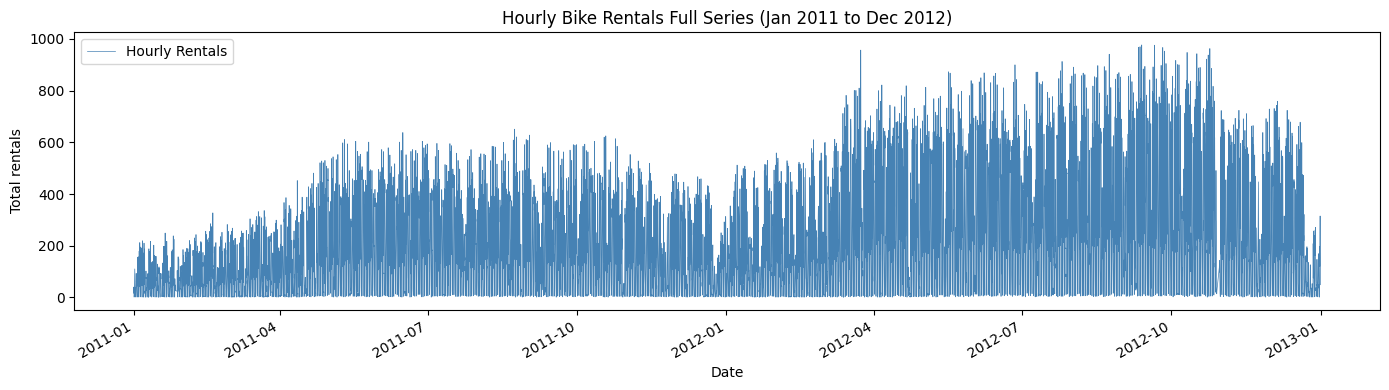

Series length : 17,379 hourly observations
Date range    : 2011-01-01 00:00:00 → 2012-12-31 23:00:00
Min - Max     : 1 - 977

ADF Stationarity Test (Hourly Series)
ADF Statistic : -6.8229
p-value       : 0.0000
→ p-value < 0.05: The Time Series is STATIONARY (No Unit Root).


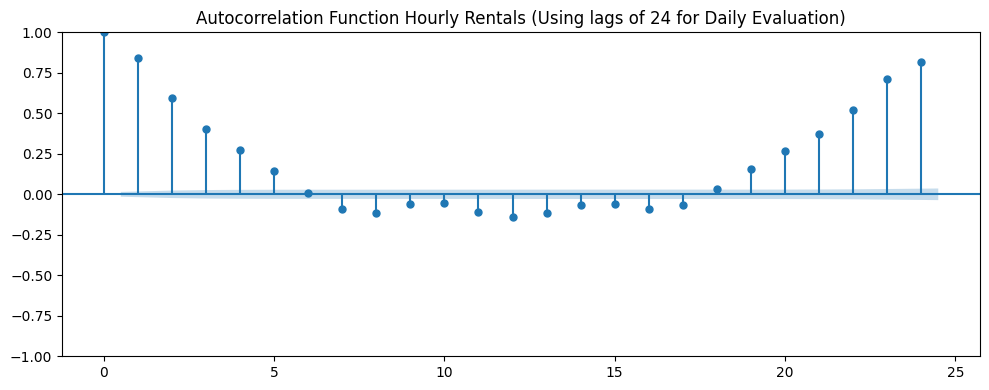

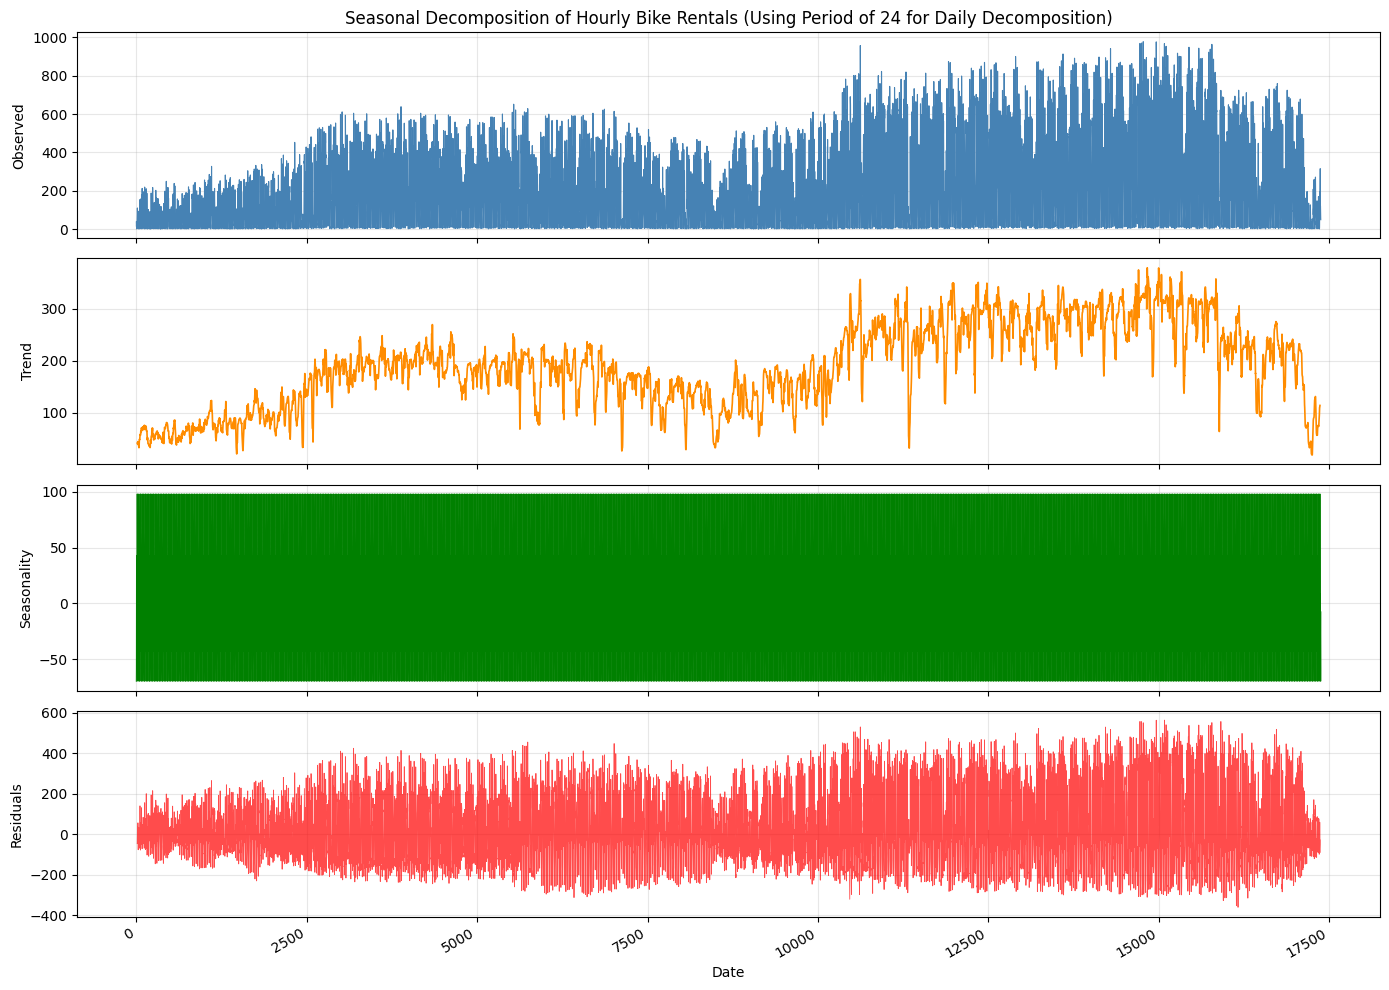

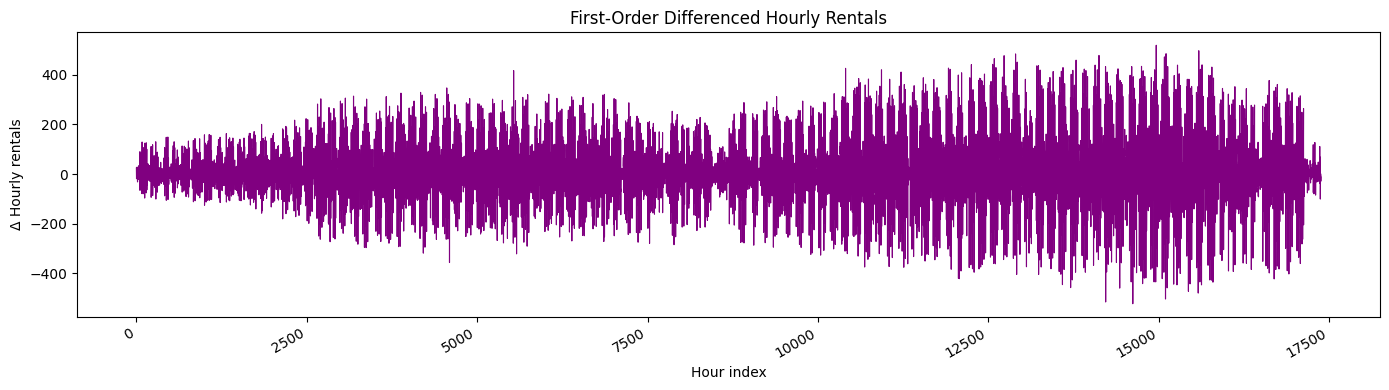


ADF Stationarity Test (Differenced Hourly Series):
ADF Statistic : -30.0916
p-value       : 0.0000
→ p-value < 0.05: differenced series is STATIONARY.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Visualize the hourly Time Series
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['datetime'], df['cnt'], linewidth=0.5, color='steelblue', label='Hourly Rentals')
ax.set_xlabel('Date')
ax.set_ylabel('Total rentals')
ax.set_title('Hourly Bike Rentals Full Series (Jan 2011 to Dec 2012)')
ax.legend(loc='upper left')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Series length : {len(df):,} hourly observations")
print(f"Date range    : {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Min - Max     : {df['cnt'].min()} - {df['cnt'].max()}")

# 2. ADF test of the Time Series
ADF_result = adfuller(df['cnt'])
print("\nADF Stationarity Test (Hourly Series)")
print(f"ADF Statistic : {ADF_result[0]:.4f}")
print(f"p-value       : {ADF_result[1]:.4f}")
if ADF_result[1] < 0.05:
    print("→ p-value < 0.05: The Time Series is STATIONARY (No Unit Root).")
else:
    print("→ p-value ≥ 0.05: The Time Series is NON-STATIONARY (Differencing Required).")

# 3. ACF test of the Time Series
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(df['cnt'], lags=24, ax=ax)
ax.set_title('Autocorrelation Function Hourly Rentals (Using lags of 24 for Daily Evaluation)')
plt.tight_layout()
plt.show()

# 5. Seasonal decomposition of the Time Series
# Period of 24 is used as daily for the decomposition
decomposition = seasonal_decompose(df['cnt'], model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(decomposition.observed, linewidth=0.8, color='steelblue')
axes[0].set_ylabel('Observed')
axes[0].set_title('Seasonal Decomposition of Hourly Bike Rentals (Using Period of 24 for Daily Decomposition)')

axes[1].plot(decomposition.trend, linewidth=1.2, color='darkorange')
axes[1].set_ylabel('Trend')

axes[2].plot(decomposition.seasonal, linewidth=0.8, color='green')
axes[2].set_ylabel('Seasonality')

axes[3].plot(decomposition.resid, linewidth=0.6, color='red', alpha=0.7)
axes[3].set_ylabel('Residuals')
axes[3].set_xlabel('Date')

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# 6. First-order differencing of the Time Series
hourly_diff = np.diff(df['cnt'].values, n=1)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(hourly_diff, linewidth=0.8, color='purple')
ax.set_xlabel('Hour index')
ax.set_ylabel('Δ Hourly rentals')
ax.set_title('First-Order Differenced Hourly Rentals')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

ADF_diff = adfuller(hourly_diff)
print("\nADF Stationarity Test (Differenced Hourly Series):")
print(f"ADF Statistic : {ADF_diff[0]:.4f}")
print(f"p-value       : {ADF_diff[1]:.4f}")
if ADF_diff[1] < 0.05:
    print("→ p-value < 0.05: differenced series is STATIONARY.")
else:
    print("→ p-value ≥ 0.05: further differencing may be needed.")

### ARMA

Train length : 579
Test length  : 16800


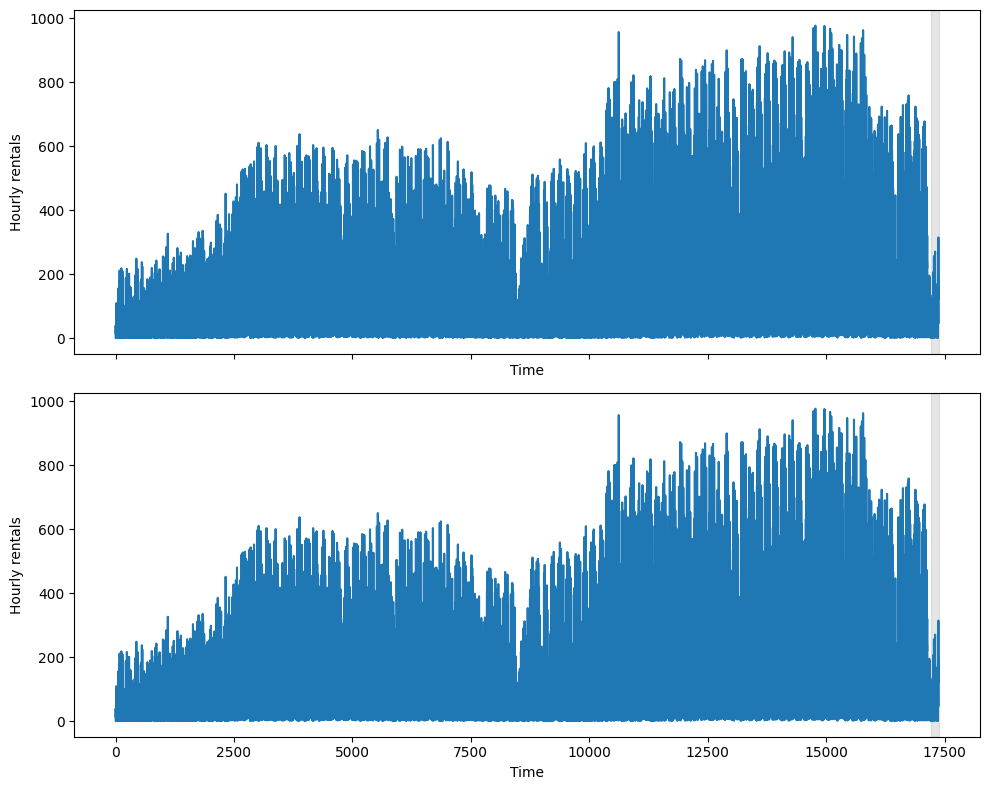

/tmp/ipykernel_11865/2118928326.py:40: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list):


  0%|          | 0/16 [00:00<?, ?it/s]

/home/enetz/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/enetz/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/enetz/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/enetz/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/enetz/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:60

     (p,q)          AIC
0   (2, 3)  5648.817720
1   (2, 2)  5652.520518
2   (1, 3)  5666.559894
3   (3, 3)  5670.279011
4   (3, 2)  5679.943817
5   (3, 1)  5700.798189
6   (3, 0)  5701.120506
7   (1, 1)  5713.122987
8   (1, 2)  5713.251843
9   (2, 1)  5714.477839
10  (2, 0)  5727.375600
11  (1, 0)  5759.181247
12  (0, 3)  5801.484955
13  (0, 2)  5873.774306
14  (0, 1)  6110.701489
15  (0, 0)  6648.024870

Fitting ARMA(2,3)


/home/enetz/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


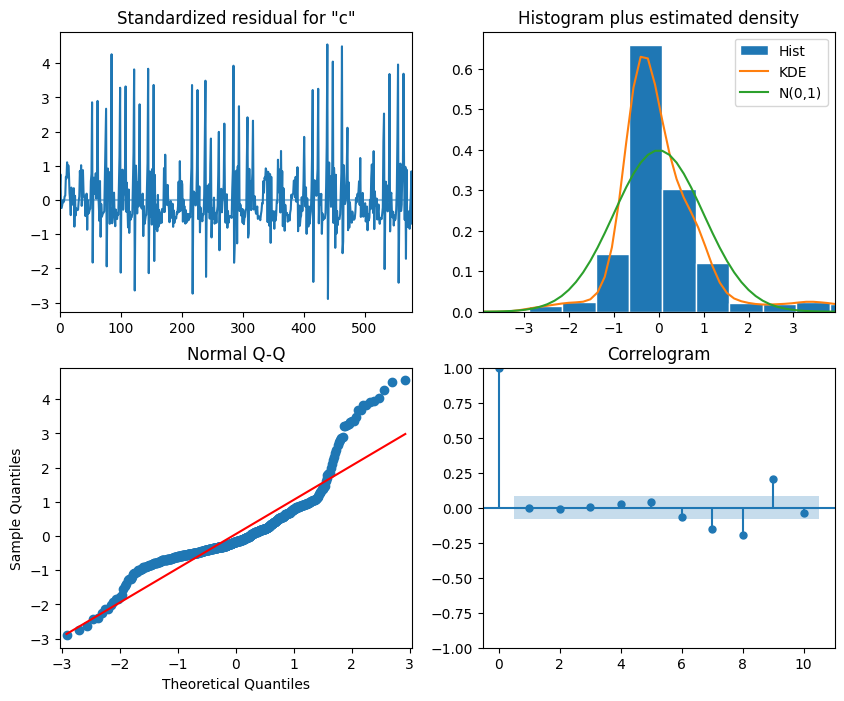

      lb_stat     lb_pvalue
1    0.007529  9.308554e-01
2    0.032000  9.841274e-01
3    0.037996  9.980524e-01
4    0.562942  9.670914e-01
5    1.409742  9.232447e-01
6    3.948300  6.836729e-01
7   17.627832  1.376688e-02
8   40.800074  2.271918e-06
9   66.237047  8.285280e-11
10  67.004889  1.673138e-10
Rolling forecast stopped after 10 convergence errors.


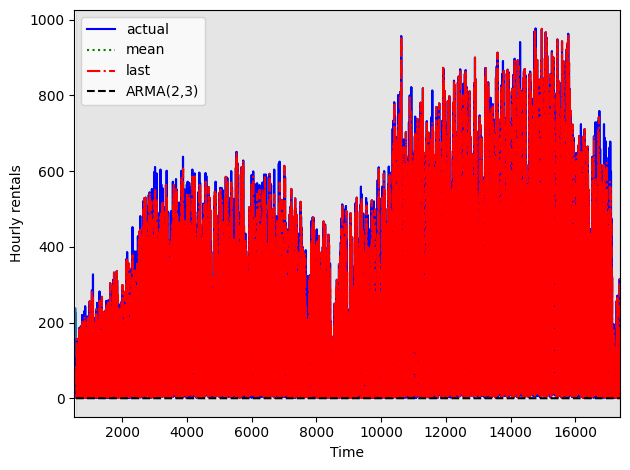

MSE mean       : 33955.3941
MSE last value : 17354.9604
MSE ARMA(2,3)  : 70971.8782


In [ ]:
# ARMA cannot be applied directly to this dataset.
#
# ARMA requires a stationary time series as input. From the Time Series Analysis section, the ADF test on the raw hourly series returned a p-value < 0.05, 
# meaning the series is already stationary. However, ARMA also requires the absence of seasonality in the residuals — the decomposition clearly shows a 
# strong repeating 24-hour (daily) seasonal pattern. ARMA has no seasonal component, so it cannot account for this structure.
#
# Nevertheless, the full general modeling procedure is applied here to document the result and justify why the model is inadequate.

# 1. Split the dataset into train/test (Use one week just to test the method)
train = df[['cnt']][:-16800]
test  = df[['cnt']][-16800:]

print(f"Train length : {len(train)}")
print(f"Test length  : {len(test)}")

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 8))
ax1.plot(df['cnt'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Hourly rentals')
ax1.axvspan(len(df) - 168, len(df), color='#808080', alpha=0.2)
ax2.plot(df['cnt'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Hourly rentals')
ax2.axvspan(len(df) - 168, len(df), color='#808080', alpha=0.2)
plt.tight_layout()
plt.show()

# 2. AIC-based order selection
def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    results = []
    for order in tqdm_notebook(order_list):
        try:
            model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
        except:
            continue
        aic = model.aic
        results.append([order, aic])
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    return result_df

ps = range(0, 4, 1)
qs = range(0, 4, 1)
order_list = list(product(ps, qs))
result_df = optimize_ARMA(train['cnt'], order_list)
print(result_df)

# 3. Residual analysis on the best ARMA order
best_p, best_q = result_df['(p,q)'].iloc[0]
print(f"\nFitting ARMA({best_p},{best_q})")

model = SARIMAX(train['cnt'], order=(best_p, 0, best_q), simple_differencing=False)
model_fit = model.fit(disp=False)
model_fit.plot_diagnostics(figsize=(10, 8))
plt.show()

residuals = model_fit.resid
print(acorr_ljungbox(residuals, np.arange(1, 11, 1)))

# 4. Rolling forecast
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    total_len = train_len + horizon

    if method == 'mean':
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
        return pred_mean

    elif method == 'last':
        pred_last_value = []
        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))
        return pred_last_value

    elif method == 'ARMA':
        pred_ARMA = []
        convergence_errors = 0
        for i in range(train_len, total_len, window):
            try:
                import warnings
                with warnings.catch_warnings():
                    warnings.filterwarnings('error', category=UserWarning)
                    model = SARIMAX(df[:i], order=(best_p, 0, best_q))
                    res = model.fit(disp=False)
            except Exception:
                convergence_errors += 1
                if convergence_errors >= 10:
                    print(f'Rolling forecast stopped after {convergence_errors} convergence errors.')
                    return pred_ARMA
                continue
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ARMA.extend(oos_pred)
        return pred_ARMA

pred_df = test.copy()
TRAIN_LEN = len(train)
HORIZON   = len(test)
WINDOW    = 2

pred_mean        = rolling_forecast(df[['cnt']], TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value  = rolling_forecast(df[['cnt']], TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_ARMA        = rolling_forecast(df[['cnt']], TRAIN_LEN, HORIZON, WINDOW, 'ARMA')

# Fill with 0 to prevent further errors and finish executing as the execution is not supposed to reach this point because of previous convergence errors
if len(pred_ARMA) < HORIZON:
    pred_ARMA = pred_ARMA + [0] * (HORIZON - len(pred_ARMA))

test = test.copy()
test.loc[:, 'pred_mean']       = pred_mean
test.loc[:, 'pred_last_value'] = pred_last_value
test.loc[:, 'pred_ARMA']       = pred_ARMA

# 5. Visualise predictions
fig, ax = plt.subplots()
ax.plot(df['cnt'])
ax.plot(test['cnt'],             'b-',  label='actual')
ax.plot(test['pred_mean'],       'g:',  label='mean')
ax.plot(test['pred_last_value'], 'r-.', label='last')
ax.plot(test['pred_ARMA'],       'k--', label=f'ARMA({best_p},{best_q})')
ax.legend(loc=2)
ax.set_xlabel('Time')
ax.set_ylabel('Hourly rentals')
ax.axvspan(TRAIN_LEN, TRAIN_LEN + HORIZON, color='#808080', alpha=0.2)
ax.set_xlim(TRAIN_LEN - 50, TRAIN_LEN + HORIZON)
plt.tight_layout()
plt.show()

# 6. MSE evaluation
from sklearn.metrics import mean_squared_error

mse_mean       = mean_squared_error(test['cnt'], test['pred_mean'])
mse_last       = mean_squared_error(test['cnt'], test['pred_last_value'])
mse_ARMA       = mean_squared_error(test['cnt'], test['pred_ARMA'])

print(f"MSE mean       : {mse_mean:.4f}")
print(f"MSE last value : {mse_last:.4f}")
print(f"MSE ARMA({best_p},{best_q})  : {mse_ARMA:.4f}")

# 7. Conclusion
# As we can see in the execution, it is supposed to fail completely, the fails are ignored and filled with 0s to finish the execution, but it clearly shows
# the method will not work with the provided data as it is not stationary and ARMA requires stationaty data to function properly.

### ARIMA

### SARIMA

### AutoArima

### Transformer Based Architecture

### Results Discussion

### Lessons Learned